In [ ]:
import tensorflow as tf

print(tf.__version__)
print(tf.config.list_physical_devices("GPU"))

In [ ]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT))

import tensorflow as tf
import matplotlib.pyplot as plt

from src.config import TRAIN_DIR, VAL_DIR, TEST_DIR
from src.dataset import load_train_val_test_datasets, optimize_dataset
from src.train_cnn import build_cnn_baseline
from src.utils import print_class_distribution

In [ ]:
print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

In [ ]:
print("Train dir:", TRAIN_DIR)
print("Val dir:", VAL_DIR)
print("Test dir:", TEST_DIR)

print("Train exists:", TRAIN_DIR.exists())
print("Val exists:", VAL_DIR.exists())
print("Test exists:", TEST_DIR.exists())

In [ ]:
train_counts = print_class_distribution(TRAIN_DIR)
val_counts = print_class_distribution(VAL_DIR)
test_counts = print_class_distribution(TEST_DIR)

In [ ]:
train_ds, val_ds, test_ds, class_names = load_train_val_test_datasets()

num_classes = len(class_names)

print("Class names:", class_names)
print("Number of classes:", num_classes)

In [ ]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [ ]:
train_ds = optimize_dataset(train_ds)
val_ds = optimize_dataset(val_ds)
test_ds = optimize_dataset(test_ds)

In [ ]:
model = build_cnn_baseline(num_classes)

model.summary()

In [ ]:
for images, labels in train_ds.take(1):
    predictions = model(images)
    print("Input batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Prediction shape:", predictions.shape)
    print("Example prediction:", predictions[0])
    break

In [ ]:
small_train_ds = train_ds.take(20)
small_val_ds = val_ds.take(5)

history = model.fit(
    small_train_ds,
    validation_data=small_val_ds,
    epochs=1
)

In [ ]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)
print("src exists:", (PROJECT_ROOT / "src").exists())

In [ ]:
from src.train_cnn import train_cnn_model
from src.config import CNN_MODEL_PATH, CNN_HISTORY_FIGURE_PATH

In [ ]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# lấy label từ train dataset
all_train_labels = []

for _, labels in train_ds:
    all_train_labels.extend(labels.numpy())

all_train_labels = np.array(all_train_labels)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(all_train_labels),
    y=all_train_labels
)

class_weight = {
    class_id: weight
    for class_id, weight in zip(np.unique(all_train_labels), class_weights_array)
}

print("Number of class weights:", len(class_weight))
print(class_weight)

In [ ]:
train_ds_for_week2 = train_ds.take(300)
val_ds_for_week2 = val_ds.take(80)

EPOCHS = 10

cnn_model, cnn_history = train_cnn_model(
    train_ds=train_ds_for_week2,
    val_ds=val_ds_for_week2,
    num_classes=num_classes,
    epochs=EPOCHS
)

In [ ]:
print("CNN model path:", CNN_MODEL_PATH)
print("Model exists:", CNN_MODEL_PATH.exists())

print("Training figure path:", CNN_HISTORY_FIGURE_PATH)
print("Figure exists:", CNN_HISTORY_FIGURE_PATH.exists())

In [ ]:
small_test_ds = test_ds.take(100)

test_loss, test_accuracy = cnn_model.evaluate(small_test_ds)

print("Small test loss:", test_loss)
print("Small test accuracy:", test_accuracy)

In [ ]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)
print("src exists:", (PROJECT_ROOT / "src").exists())

In [ ]:
from src.evaluate import evaluate_cnn_final
from src.config import CNN_MODEL_PATH, CNN_FINAL_RESULT_PATH

In [ ]:
from src.dataset import load_train_val_test_datasets

train_ds, val_ds, test_ds, class_names = load_train_val_test_datasets()
num_classes = len(class_names)

print("Number of classes:", num_classes)
print("CNN model path:", CNN_MODEL_PATH)
print("Model exists:", CNN_MODEL_PATH.exists())

In [ ]:
cnn_final_model, cnn_test_loss, cnn_test_accuracy = evaluate_cnn_final(test_ds)

print("CNN final test loss:", cnn_test_loss)
print("CNN final test accuracy:", cnn_test_accuracy)
print("CNN final test accuracy percent:", cnn_test_accuracy * 100)

In [ ]:
small_test_ds = test_ds.take(100)

cnn_final_model, cnn_test_loss, cnn_test_accuracy = evaluate_cnn_final(small_test_ds)

print("CNN final small test loss:", cnn_test_loss)
print("CNN final small test accuracy:", cnn_test_accuracy)
print("CNN final small test accuracy percent:", cnn_test_accuracy * 100)

In [ ]:
print("Final result path:", CNN_FINAL_RESULT_PATH)
print("Final result exists:", CNN_FINAL_RESULT_PATH.exists())

if CNN_FINAL_RESULT_PATH.exists():
    print(CNN_FINAL_RESULT_PATH.read_text(encoding="utf-8"))

## Week 3 - CNN Optimization

In [4]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)
print("src exists:", (PROJECT_ROOT / "src").exists())

PROJECT_ROOT: /mnt/d/School/traffic-sign-recognition
src exists: True


In [2]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

from src.dataset import load_train_val_test_datasets
from src.train_cnn import train_cnn_model
from src.config import CNN_MODEL_PATH, CNN_HISTORY_FIGURE_PATH

train_ds, val_ds, test_ds, class_names = load_train_val_test_datasets()
num_classes = len(class_names)

print("Number of classes:", num_classes)
print("Class names:", class_names)

I0000 00:00:1777968943.309655     671 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777968943.937618     671 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777968946.773496     671 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Found 31367 files belonging to 43 classes.


I0000 00:00:1777968950.522747     671 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2246 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5


Found 7842 files belonging to 43 classes.
Found 12630 files belonging to 43 classes.
Number of classes: 43
Class names: ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '5', '6', '7', '8', '9']


In [3]:
all_train_labels = []

for _, labels in train_ds:
    all_train_labels.extend(labels.numpy())

all_train_labels = np.array(all_train_labels)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(all_train_labels),
    y=all_train_labels
)

class_weight = {
    int(class_id): float(weight)
    for class_id, weight in zip(np.unique(all_train_labels), class_weights_array)
}

print("Number of class weights:", len(class_weight))
print(class_weight)

Number of class weights: 43
{0: 4.342054263565892, 1: 0.41073486276974647, 2: 0.4536474603725558, 3: 0.6907813601127555, 4: 0.43420542635658915, 5: 0.4221441645133506, 6: 1.169014609421586, 7: 1.4473514211886305, 8: 2.171027131782946, 9: 0.8214697255394929, 10: 0.759859496124031, 11: 4.342054263565892, 12: 0.40525839793281654, 13: 2.5328649870801034, 14: 2.763125440451022, 15: 2.338029218843172, 16: 1.787904696762426, 17: 3.3771533161068046, 18: 0.6078875968992248, 19: 1.519718992248062, 20: 3.799297480620155, 21: 1.6885766580534023, 22: 3.3771533161068046, 23: 0.6466889328715157, 24: 2.0262919896640827, 25: 1.169014609421586, 26: 3.799297480620155, 27: 1.3238931329928671, 28: 2.171027131782946, 29: 0.759859496124031, 30: 2.338029218843172, 31: 4.342054263565892, 32: 0.44049825862262665, 33: 3.039437984496124, 34: 0.460520906741837, 35: 2.5328649870801034, 36: 3.799297480620155, 37: 3.799297480620155, 38: 0.4902319329832458, 39: 2.171027131782946, 40: 0.6332162467700259, 41: 0.64668893

Epoch 1/20


E0000 00:00:1777969014.303076     671 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/cnn_baseline_optimized_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1777969016.601949    1266 cuda_dnn.cc:461] Loaded cuDNN version 92101


700/700 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.0531 - loss: 3.8300
Epoch 1: val_accuracy improved from None to 0.05229, saving model to /mnt/d/School/traffic-sign-recognition/models/cnn_baseline.keras
700/700 ━━━━━━━━━━━━━━━━━━━━ 105s 133ms/step - accuracy: 0.0699 - loss: 3.5729 - val_accuracy: 0.0523 - val_loss: 3.4987 - learning_rate: 0.0010
Epoch 2/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.1084 - loss: 3.0158
Epoch 2: val_accuracy improved from 0.05229 to 0.18875, saving model to /mnt/d/School/traffic-sign-recognition/models/cnn_baseline.keras
700/700 ━━━━━━━━━━━━━━━━━━━━ 85s 121ms/step - accuracy: 0.1186 - loss: 2.9512 - val_accuracy: 0.1887 - val_loss: 2.7598 - learning_rate: 0.0010
Epoch 3/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.1560 - loss: 2.6206
Epoch 3: val_accuracy did not improve from 0.18875
700/700 ━━━━━━━━━━━━━━━━━━━━ 83s 118ms/step - accuracy: 0.1716 - loss: 2.5688 - val_accuracy: 0.1765 - val_loss: 3.6270 - learning_rate:

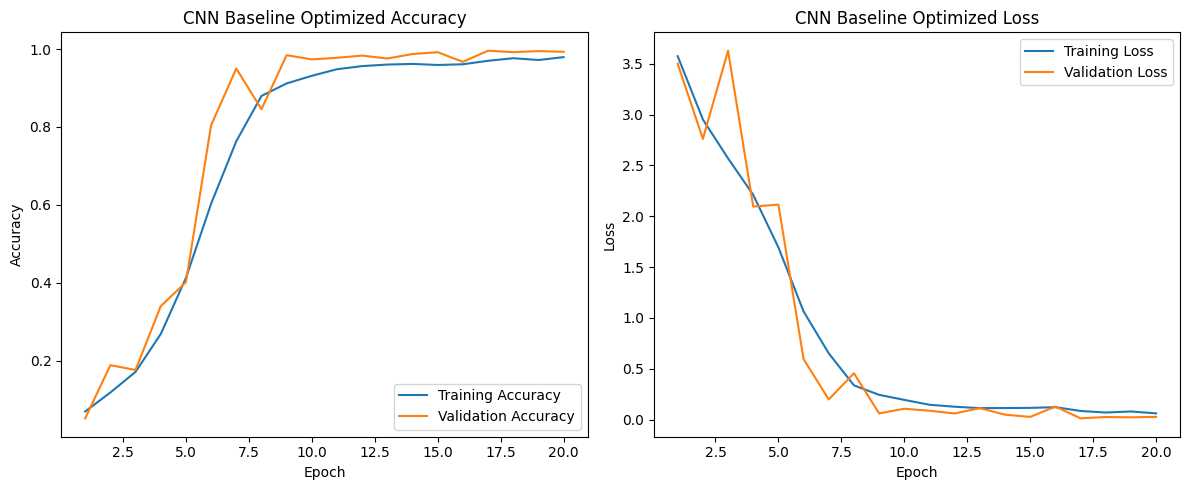

Training history figure saved to: /mnt/d/School/traffic-sign-recognition/results/figures/cnn_accuracy_loss.png


In [4]:
train_ds_for_optimize = train_ds.take(700)
val_ds_for_optimize = val_ds.take(150)

EPOCHS = 20

optimized_cnn_model, optimized_cnn_history = train_cnn_model(
    train_ds=train_ds_for_optimize,
    val_ds=val_ds_for_optimize,
    num_classes=num_classes,
    epochs=EPOCHS,
    class_weight=class_weight
)

In [3]:
print("Optimized CNN model path:", CNN_MODEL_PATH)
print("Model exists:", CNN_MODEL_PATH.exists())

print("Optimized training figure path:", CNN_HISTORY_FIGURE_PATH)
print("Figure exists:", CNN_HISTORY_FIGURE_PATH.exists())

NameError: name 'CNN_MODEL_PATH' is not defined

In [ ]:
small_test_ds = test_ds.take(100)

opt_test_loss, opt_test_accuracy = optimized_cnn_model.evaluate(small_test_ds)

print("Optimized small test loss:", opt_test_loss)
print("Optimized small test accuracy:", opt_test_accuracy)
print("Optimized small test accuracy percent:", opt_test_accuracy * 100)

In [ ]:
opt_full_test_loss, opt_full_test_accuracy = optimized_cnn_model.evaluate(test_ds)

print("Optimized full test loss:", opt_full_test_loss)
print("Optimized full test accuracy:", opt_full_test_accuracy)
print("Optimized full test accuracy percent:", opt_full_test_accuracy * 100)